In [1]:
import math
from itertools import combinations

from pathlib import Path

import numpy as np
import pandas as pd

from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
## Visualize Direct Pairings ##

results_df = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/power_simulation/direct_overlap_simulation.csv', index_col=0)
results_df = results_df[results_df['simulation_status'] == 'success']

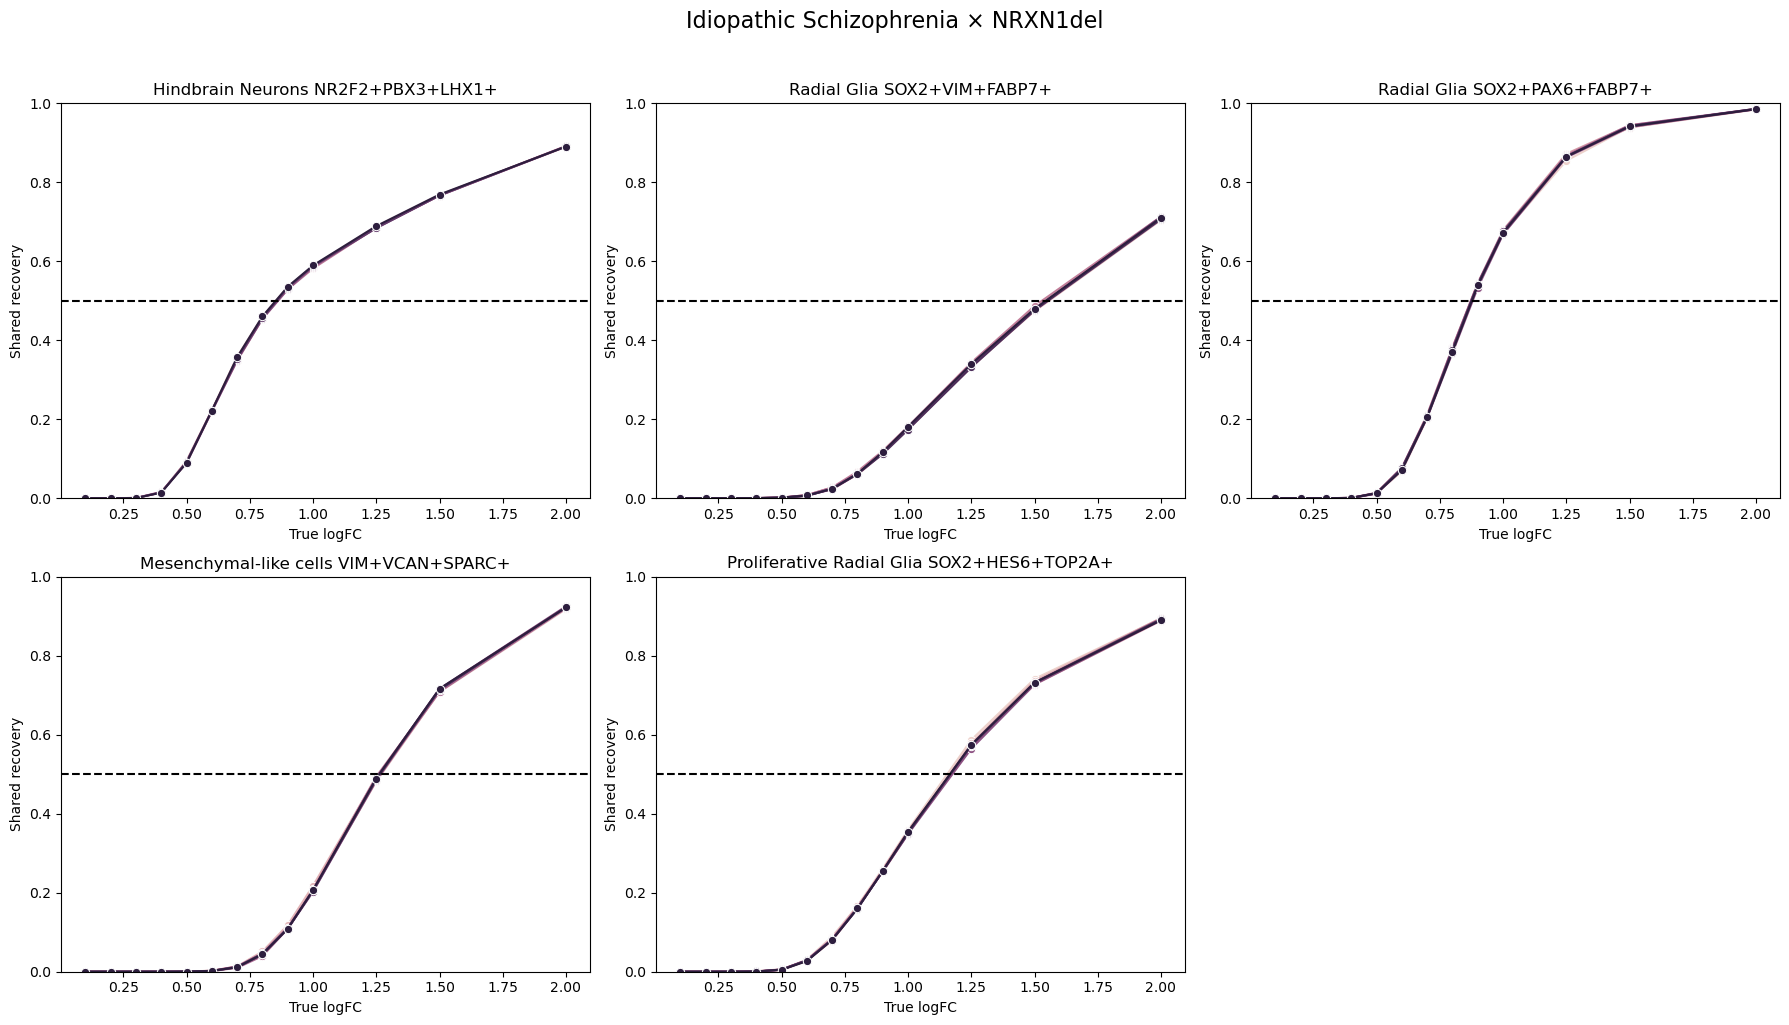

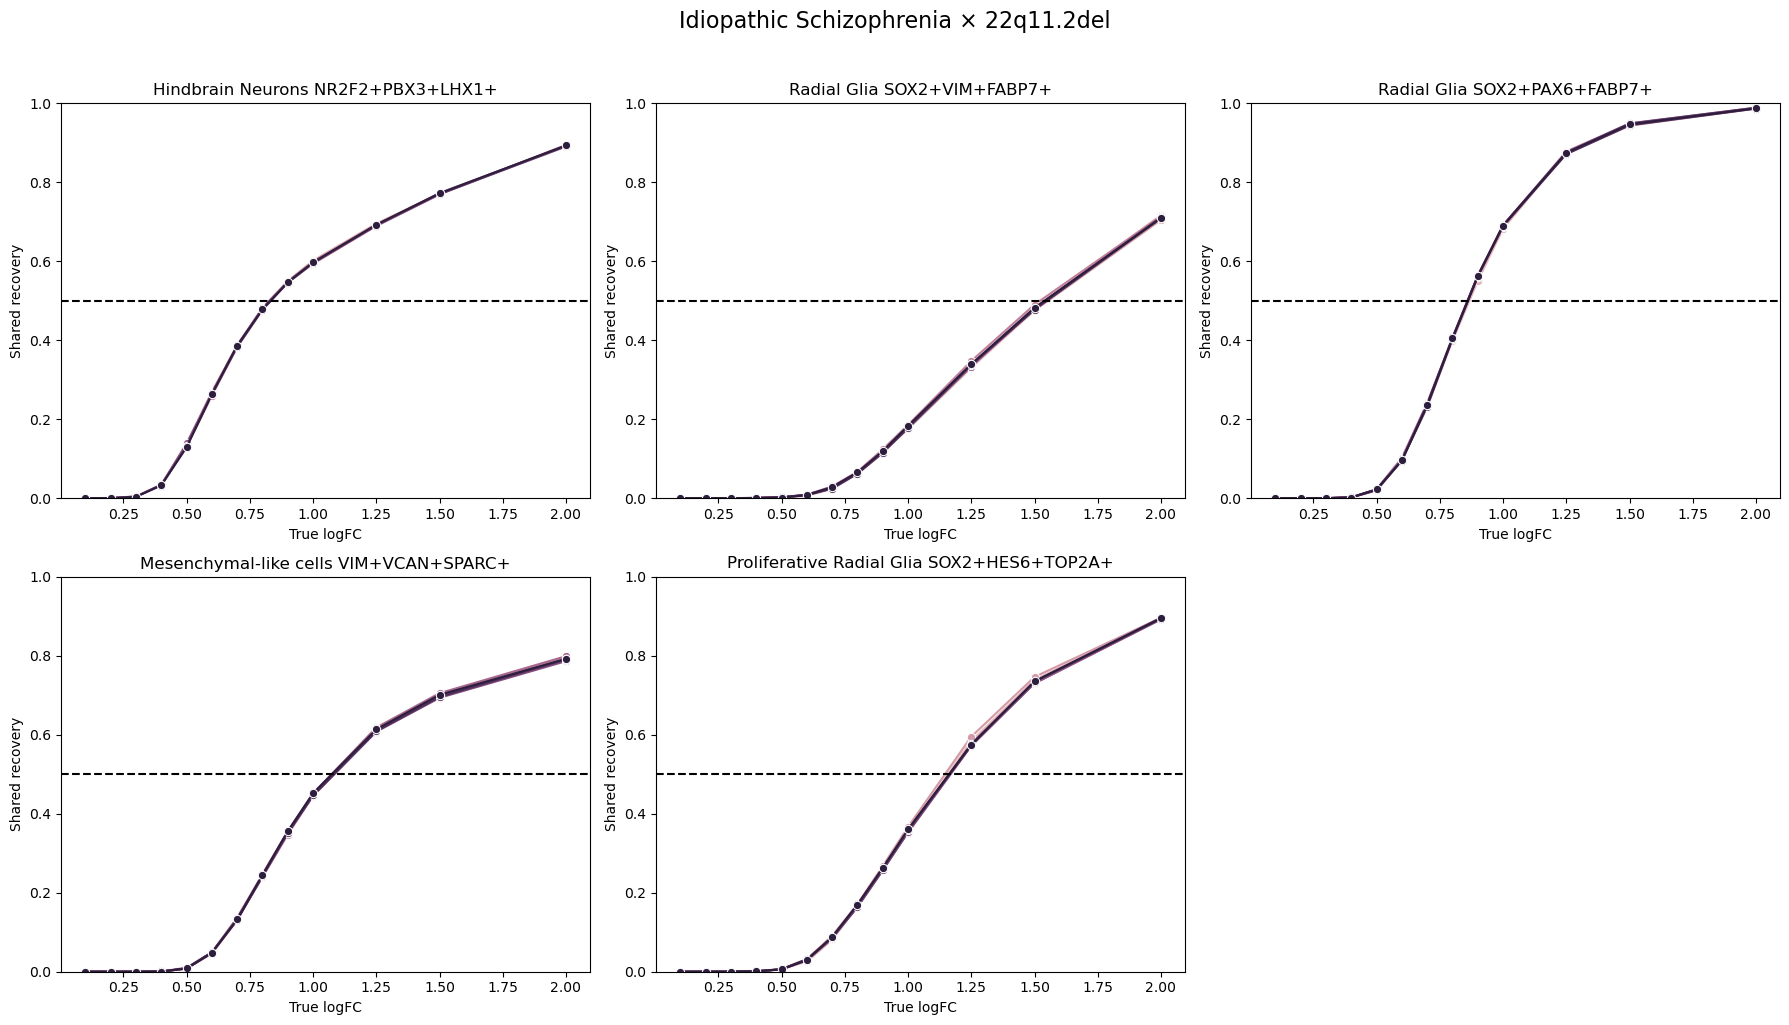

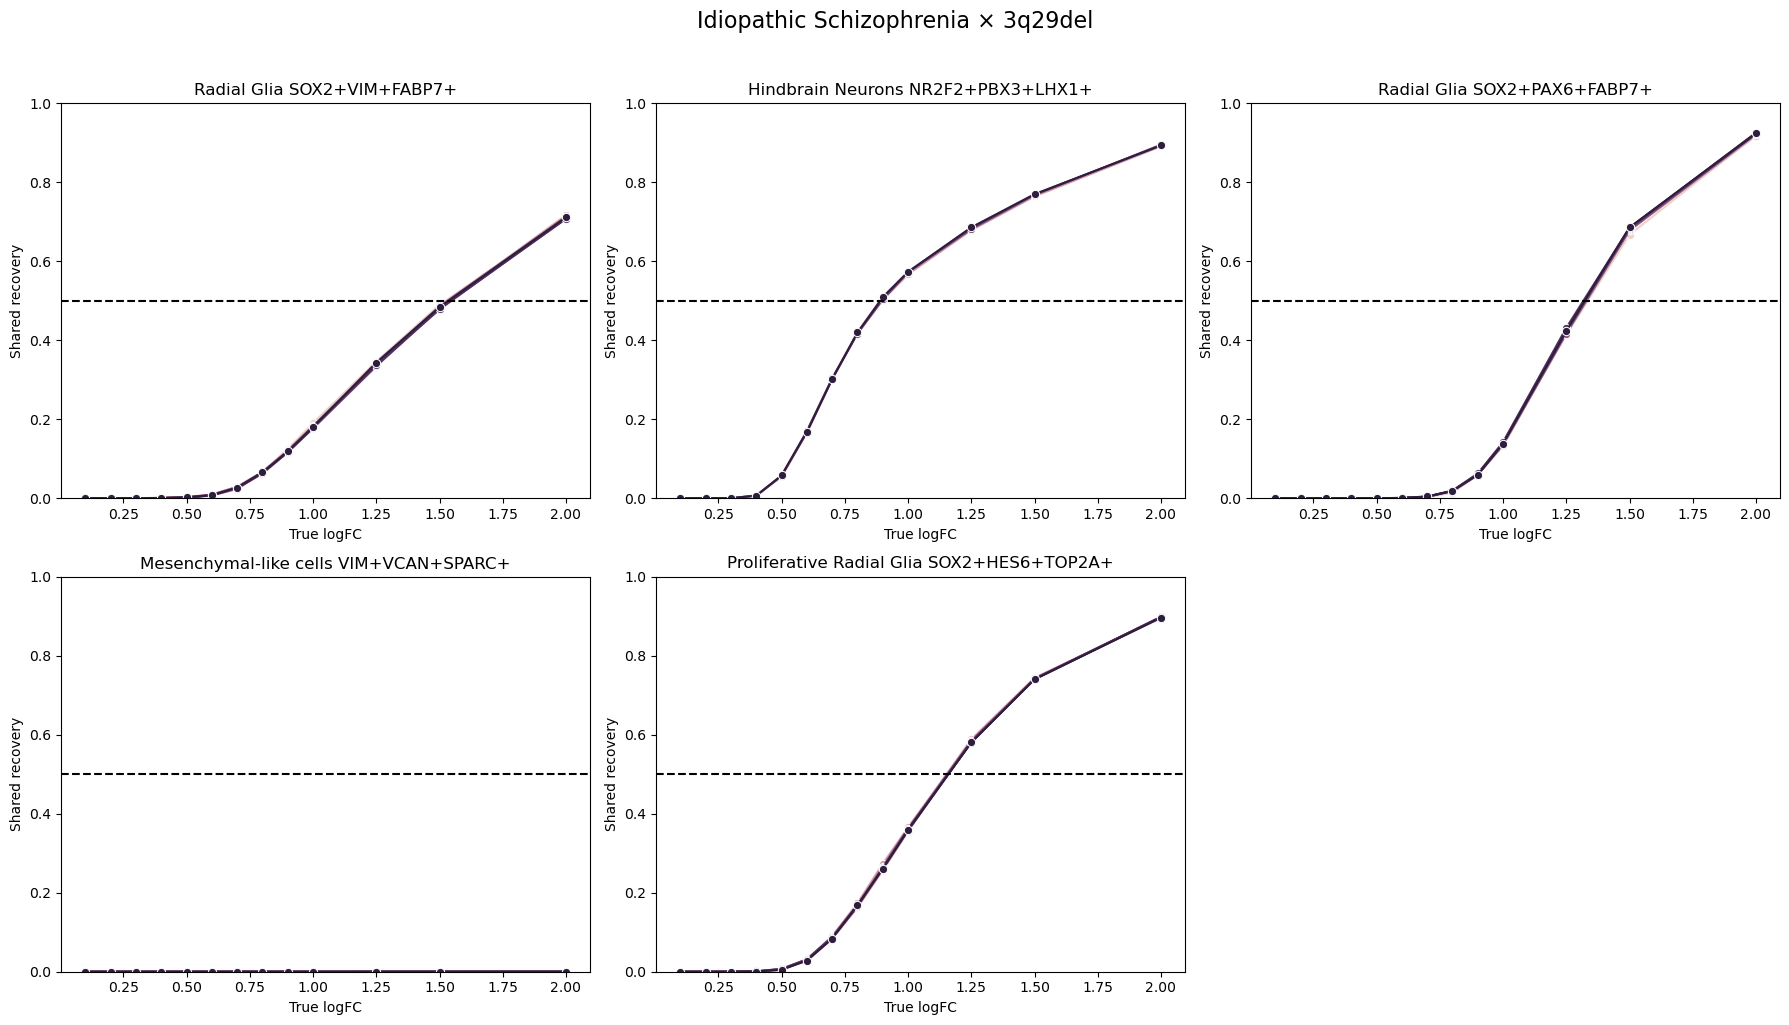

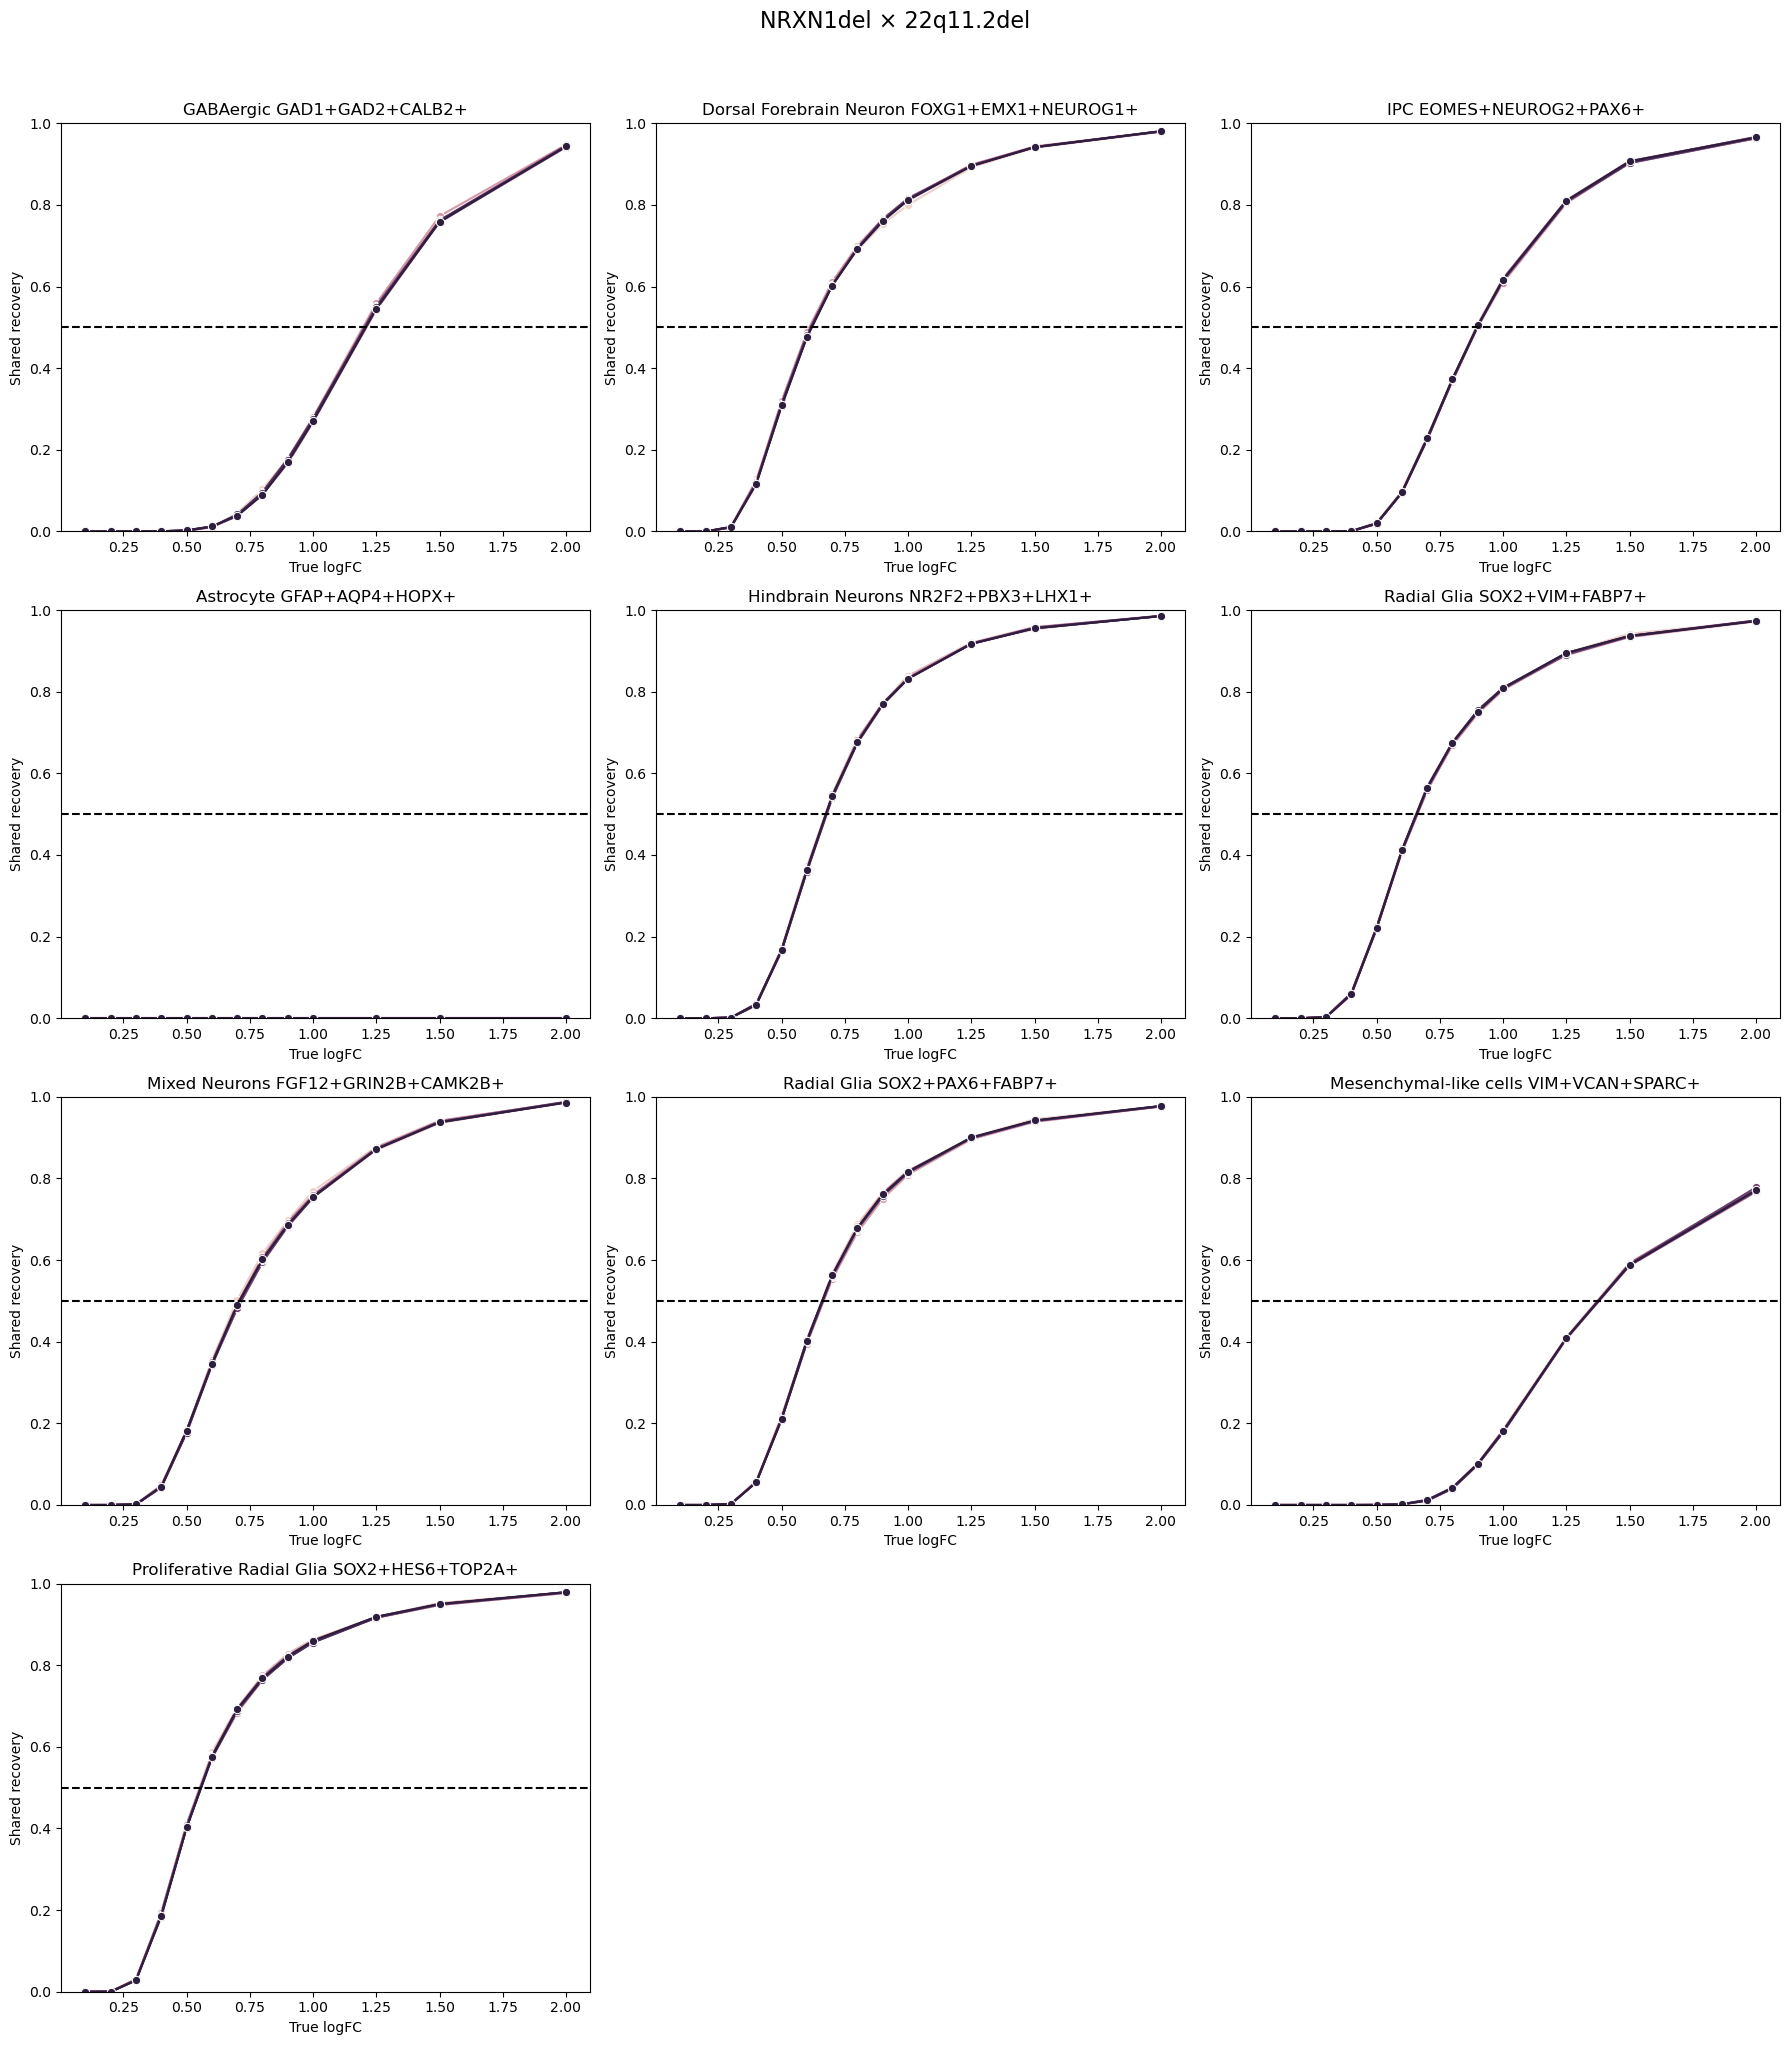

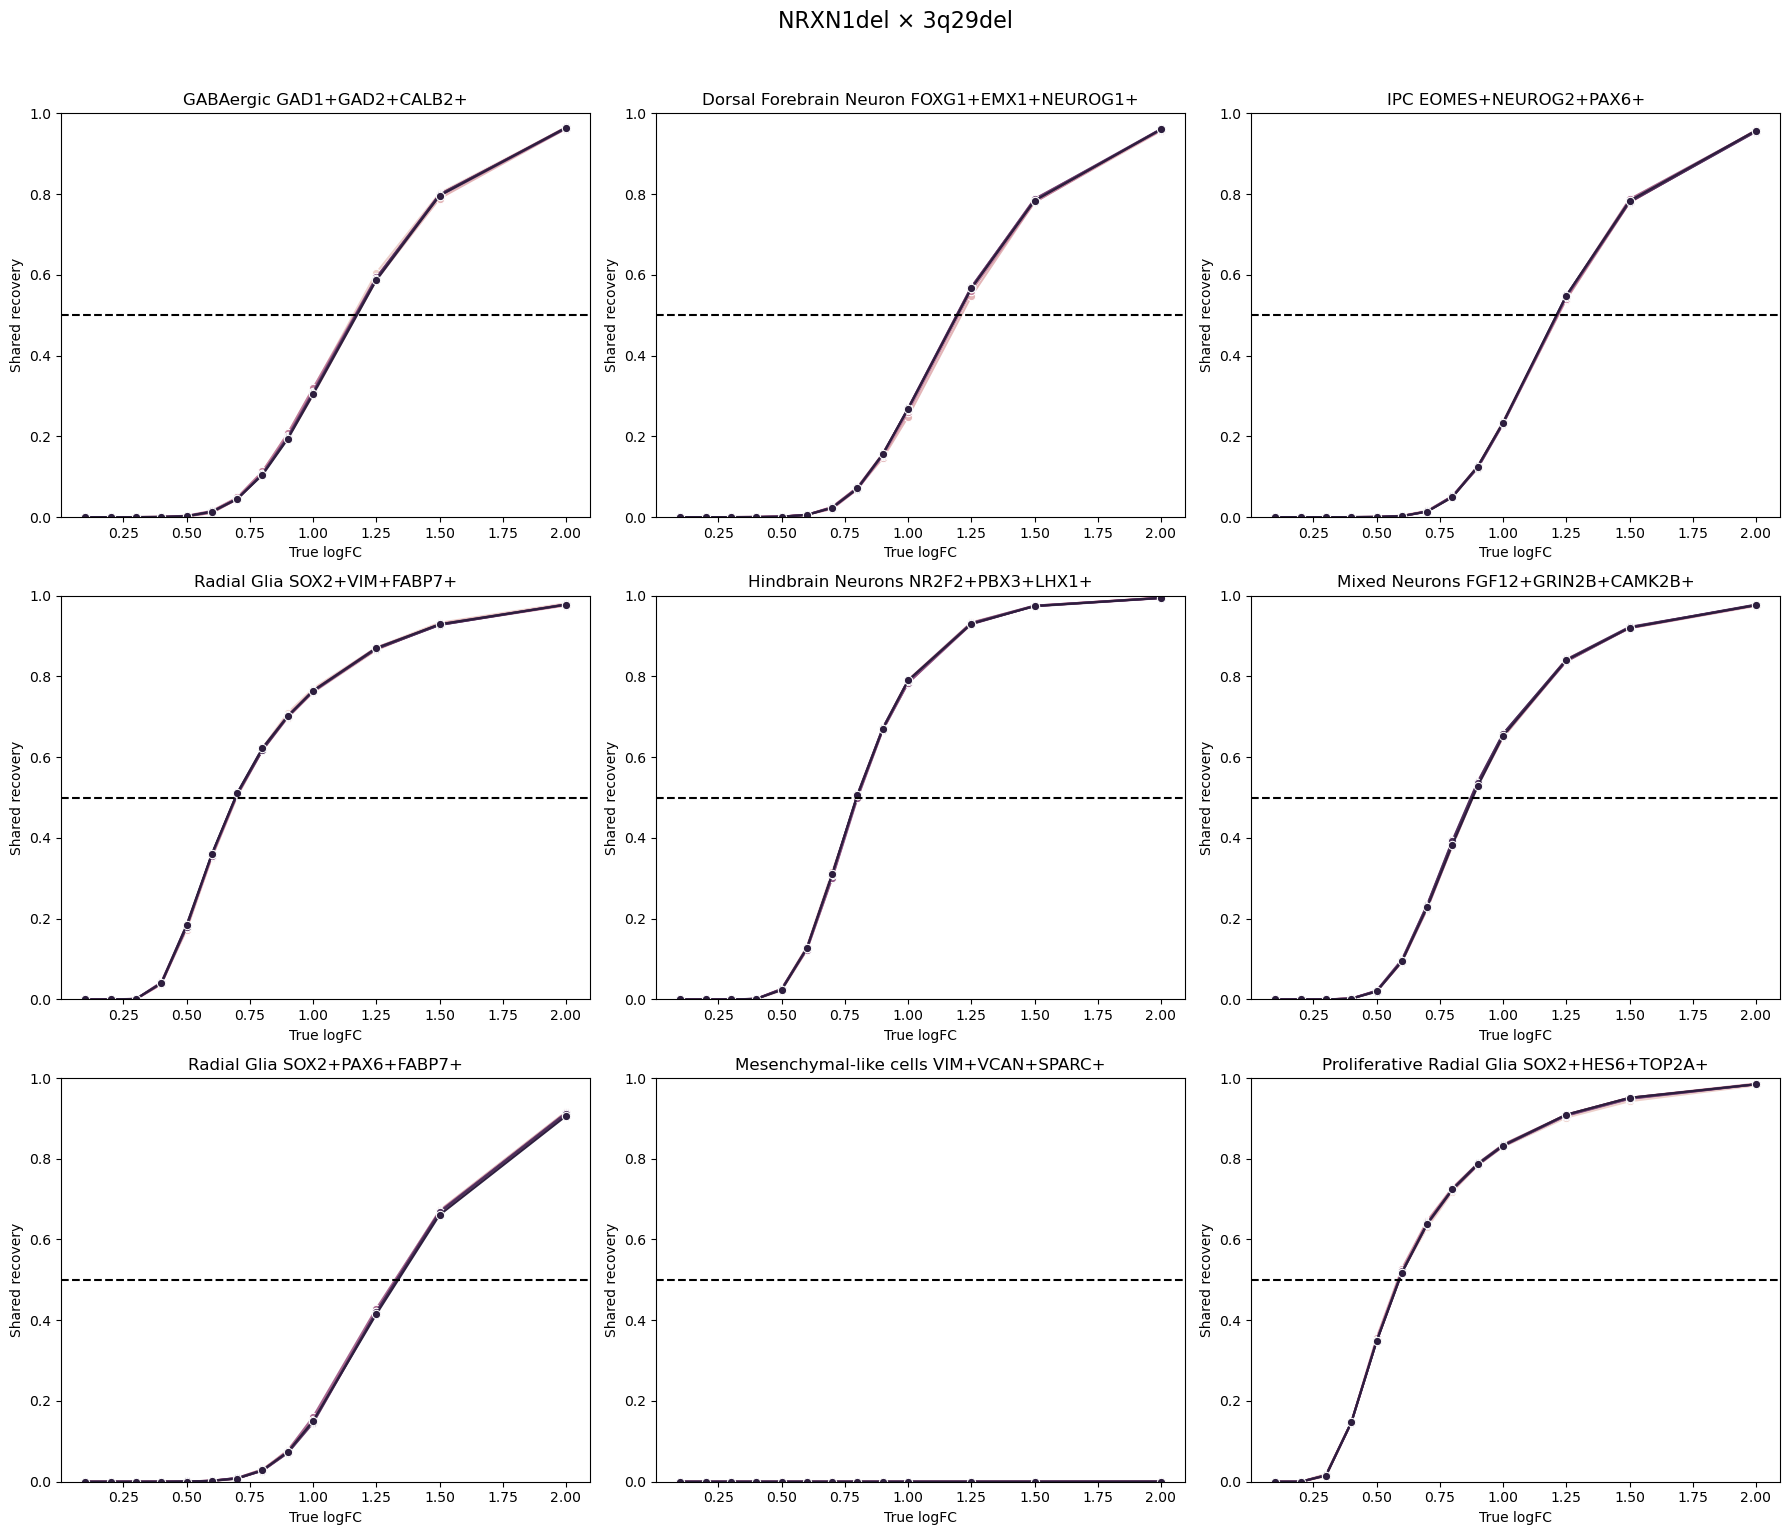

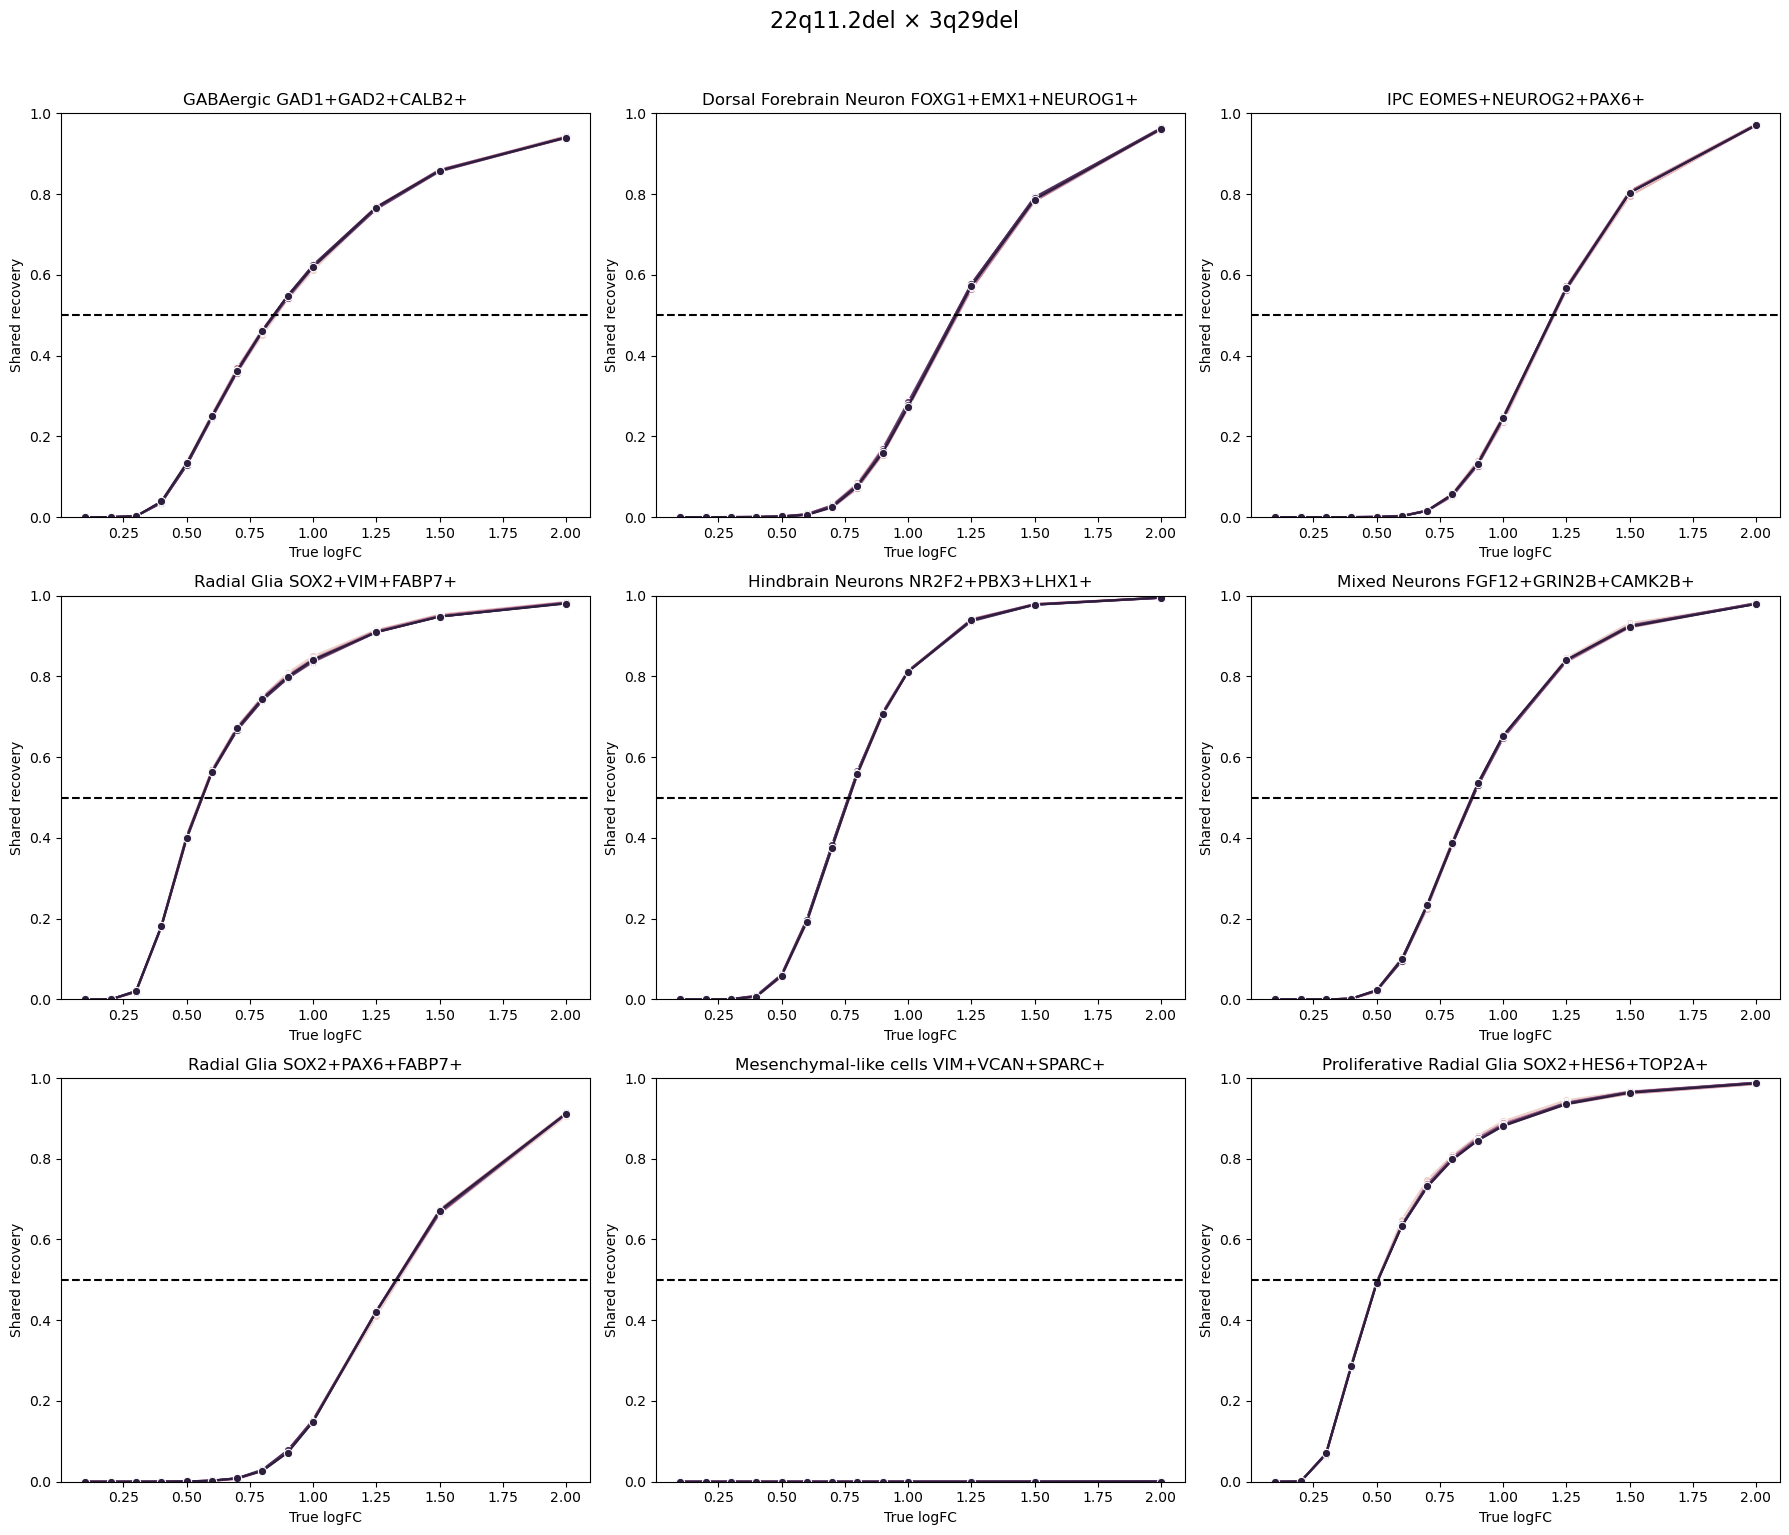

In [3]:
## One Figure Per Disease-Pairing, 1 Panel Per CellType ##

disease_pairs = list(combinations(results_df['disease_a'].unique(), 2))

for pairing in disease_pairs:

    pairing_bool = (results_df['disease_a'].isin(pairing) & results_df['disease_b'].isin(pairing))
    test_df = results_df[pairing_bool]

    celltypes = test_df['celltype'].unique()

    ncols = 3
    nrows = int(np.ceil(len(celltypes) / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
    axes = np.array(axes).flatten()

    for ax, celltype in zip(axes, celltypes):

        test_df_celltype = test_df[test_df['celltype'] == celltype]

        summary = test_df_celltype.groupby(['logFC', 'shared_fraction'])['shared_recovery'].mean().reset_index()

        sns.lineplot(data=summary, x='logFC', y='shared_recovery', hue='shared_fraction', marker='o', ax=ax, legend=False)

        ax.axhline(0.5, color='black', linestyle='--')
        ax.set_title(celltype)
        ax.set_ylim(0, 1)
        ax.set_xlabel('True logFC')
        ax.set_ylabel('Shared recovery')

    for ax in axes[len(celltypes):]:
        ax.remove()

    fig.suptitle(f'{pairing[0]} × {pairing[1]}', fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()


In [4]:
diseases = pd.unique(results_df[['disease_a', 'disease_b']].values.ravel())
disease_pairs = list(combinations(diseases, 2))

results = []

for pairing in disease_pairs:

    pairing_bool = (results_df['disease_a'].isin(pairing) & results_df['disease_b'].isin(pairing))
    test_df = results_df[pairing_bool & (results_df['shared_fraction'] == 0.5)]

    summary = test_df.groupby(['celltype', 'logFC'])['shared_recovery'].mean().reset_index()

    summary_80 = summary[summary['shared_recovery'] >= 0.5]

    min_logFC = summary_80.groupby('celltype')['logFC'].min().reset_index()

    min_logFC['disease_pair'] = f'{pairing[0]} × {pairing[1]}'

    results.append(min_logFC)

min_logFC_df = pd.concat(results, ignore_index=True)


/tmp/ipykernel_692963/1770365992.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Reds').copy()


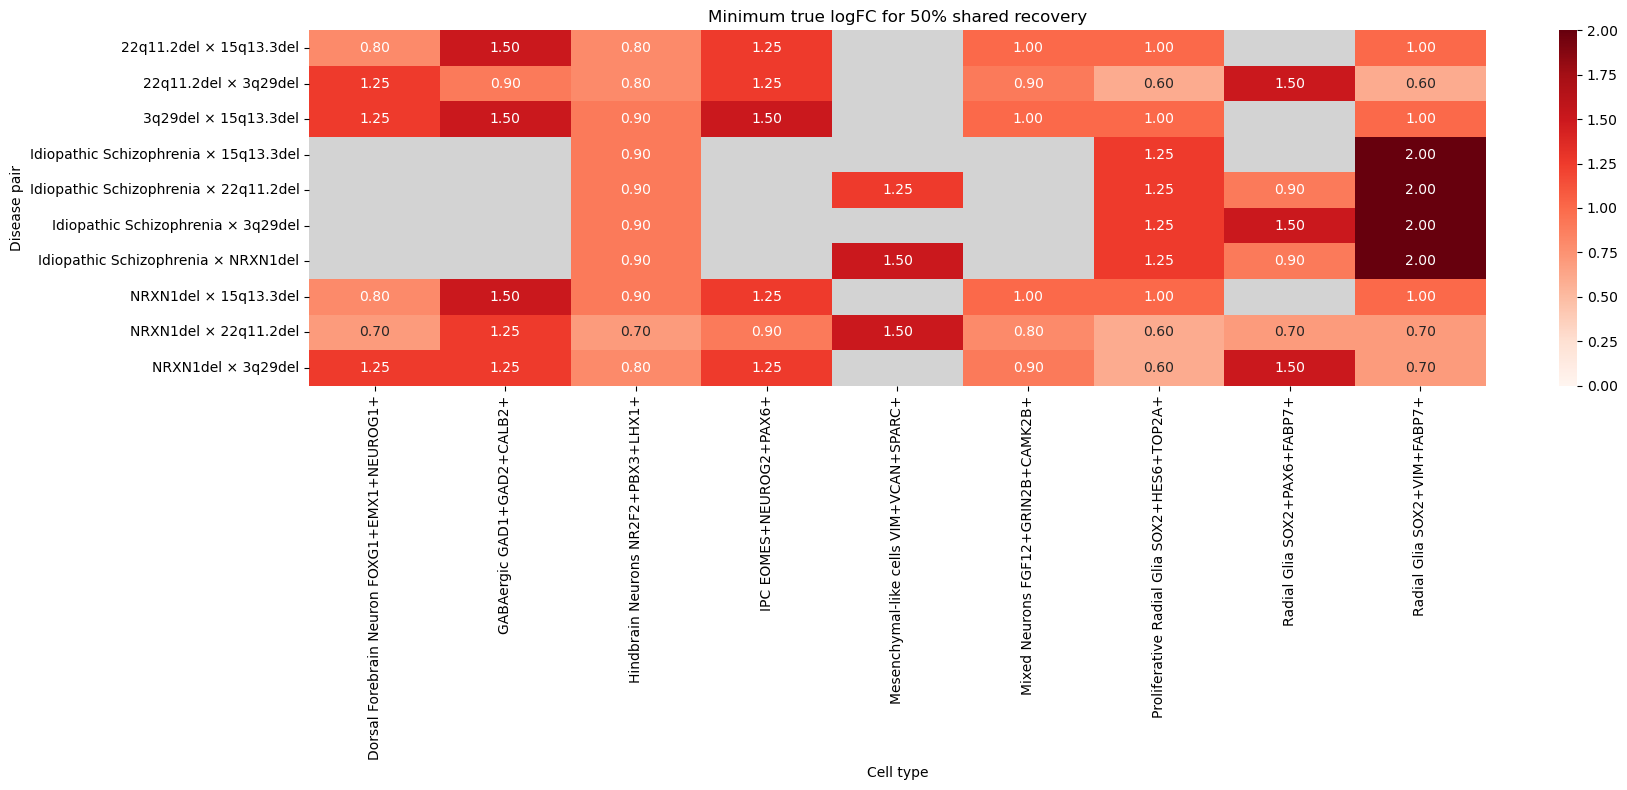

In [8]:
cmap = plt.cm.get_cmap('Reds').copy()
cmap.set_bad('lightgray')

heatmap_data = min_logFC_df.pivot(index='disease_pair', columns='celltype', values='logFC')

plt.figure(figsize=(18, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    vmin=0,
    vmax=2
)

plt.xlabel('Cell type')
plt.ylabel('Disease pair')
plt.title('Minimum true logFC for 50% shared recovery')

plt.tight_layout()
plt.show()


In [6]:
results_df = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/power_simulation/direct_overlap_simulation.csv', index_col=0)

In [7]:
idio_a_bool = (results_df['disease_a'] == 'Idiopathic Schizophrenia')
idio_b_bool = (results_df['disease_b'] == 'Idiopathic Schizophrenia')

results_df[idio_a_bool | idio_b_bool][['simulation_status', 'disease_b']].value_counts()

simulation_status   disease_b 
success             22q11.2del    54600
                    NRXN1del      54600
                    3q29del       53300
                    15q13.3del    42900
insufficient_genes  3q29del       28600
                    15q13.3del    27300
                    22q11.2del    27300
                    NRXN1del      27300
Name: count, dtype: int64